In [57]:
import pandas as pd
import numpy as np
from pathlib import Path 

np.random.seed(42)
frequency = 64
path = Path(f"data/raw/dreamt/data_{frequency}Hz")

COLS_TO_DROP = [
    "TIMESTAMP",
    "IBI",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
]
nb_patients = 25
X_all_patients = []
y_all_patients = []
patient_file_list = [f for f in path.iterdir() if f.is_file()]
for patient_id in range(nb_patients):
    patient_file = patient_file_list.pop() 
    df = pd.read_csv(patient_file)
    df = df.drop(
                columns=COLS_TO_DROP
            )
    df = df[~df["Sleep_Stage"].isin(["Missing","P"])]    
    y_all_patients.append(df.Sleep_Stage.to_numpy())
    X_all_patients.append(df.drop(columns=["Sleep_Stage"]).to_numpy())


In [58]:
WINDOWS_SEC = 30
FS = 64

window_samples = FS * WINDOWS_SEC

X_bvp_patients = []
X_acc_patients = []
X_eda_temp_patients = []
X_hr_patients = []
y_patients = []

for patient in range(len(X_all_patients)):
    X_bvp = []
    X_acc = []
    X_eda_temp = []
    X_hr = []
    y = []
    data = X_all_patients[patient]
    T = data.shape[0]
    n_windows = T // window_samples
    for i in range(n_windows):
        start = i * window_samples
        end = start + window_samples
        # 1920, 
        X_bvp.append(data[start:end,0])
        # 960
        X_acc.append(data[start:end:2, 1:4])
        # 120
        X_eda_temp.append(data[start:end:16, 4:6])
        # 30
        X_hr.append(data[start:end:64, 6])
        #1
        y.append(y_all_patients[patient][start])
    
    X_bvp_patients.append(np.stack(X_bvp))
    X_acc_patients.append(np.stack(X_acc))
    X_hr_patients.append(np.stack(X_hr))
    X_eda_temp_patients.append(np.stack(X_eda_temp))
    y_patients.append(np.array(y))
        


In [59]:
X_bvp_train = []
X_bvp_test = []

X_acc_train = []
X_acc_test = []

X_eda_temp_train = []
X_eda_temp_test = []

X_hr_train = []
X_hr_test = []

y_train = []
y_test = []

test_size = 0.2

test_patients = np.random.choice(nb_patients, size= int(test_size * nb_patients))

for patient in range(nb_patients):
    if patient not in test_patients:
        X_bvp_train.append(X_bvp_patients[patient])
        X_acc_train.append(X_acc_patients[patient])
        X_eda_temp_train.append(X_eda_temp_patients[patient])
        X_hr_train.append(X_hr_patients[patient])
        y_train.append(y_patients[patient])

    else:
        X_bvp_test.append(X_bvp_patients[patient])
        X_acc_test.append(X_acc_patients[patient])
        X_eda_temp_test.append(X_eda_temp_patients[patient])
        X_hr_test.append(X_hr_patients[patient])
        y_test.append(y_patients[patient])



X_bvp_train =np.concatenate(X_bvp_train)
X_bvp_test =np.concatenate(X_bvp_test)

X_acc_train =np.concatenate(X_acc_train)
X_acc_test =np.concatenate(X_acc_test)

X_eda_temp_train =np.concatenate(X_eda_temp_train)
X_eda_temp_test =np.concatenate(X_eda_temp_test)

X_hr_train =np.concatenate(X_hr_train)
X_hr_test =np.concatenate(X_hr_test)

y_train = np.concatenate(y_train)
y_test = np.concatenate(y_test)


X_bvp_train = np.expand_dims(X_bvp_train, axis=1)
X_eda_temp_train = np.permute_dims(X_eda_temp_train, axes=[0,2,1])
X_acc_train = np.permute_dims(X_acc_train, axes=[0,2,1])

In [60]:
X_bvp_test      = np.expand_dims(X_bvp_test, axis=1)
X_eda_temp_test = np.permute_dims(X_eda_temp_test, axes=[0,2,1])
X_acc_test      = np.permute_dims(X_acc_test, axes=[0,2,1])

In [61]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

y_train_encoded

array([4, 4, 4, ..., 1, 1, 1], shape=(16100,))

In [62]:
lb.classes_ 

array(['N1', 'N2', 'N3', 'R', 'W'], dtype='<U2')

In [63]:

import torch 
import torch.nn as nn 


class Residual(nn.Module):
    def __init__(self, input_size, hidden_size, kernel_size = 3, dilation_depth = 3):
        super().__init__()
        self.blocks = nn.ModuleList()
        original_input_size = input_size
        for i in range(dilation_depth): 
            dilation = 2 ** i 
            self.blocks.append(nn.Sequential(
            nn.ZeroPad1d(padding=((kernel_size -1) * dilation,0)),
            nn.Conv1d(in_channels=input_size, out_channels =hidden_size, kernel_size=kernel_size, 
                                dilation=dilation),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
            ))
            input_size = hidden_size

        self.drop_out = nn.Dropout1d(0.5)
        self.align = nn.Conv1d(original_input_size, hidden_size, 1)  \
                if original_input_size != hidden_size else nn.Identity()
 


    def forward(self, input):
        x = input 
        for block in self.blocks:
            x = block(x)

        x = self.drop_out(x)

        return self.align(input) + x 
    


class MultiTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.bc_bvp = nn.BatchNorm1d(1)
        self.bc_acc = nn.BatchNorm1d(3)
        self.bc_temp = nn.BatchNorm1d(2)
        self.bc_hr = nn.BatchNorm1d(1)

        self.bvp_block = Residual(1, 16, dilation_depth=10)
        self.acc_block = Residual(3, 16, dilation_depth=9)
        self.eda_temp_block = Residual(2, 16, dilation_depth=6)
        self.hr_block = Residual(1, 16, dilation_depth=4)

        target_length = 120


        self.avg_bvp = nn.AvgPool1d(kernel_size=1920 // target_length)
        self.avg_acc = nn.AvgPool1d(kernel_size=960 // target_length)    
        self.avg_temp = nn.AvgPool1d(kernel_size=120 // target_length)   

        self.fc = nn.Sequential(
            nn.Linear(16 * target_length * 3 + 30, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 5),
        ) 

        self.init_weights()

    def init_weights(self):
        for layer in self.modules():
            if isinstance(layer, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
            
    def forward(self, x_bvp, x_acc, x_eda_temp, x_hr):
        x_hr = x_hr.unsqueeze(1)
        x_bvp  = self.bc_bvp(x_bvp)
        x_acc = self.bc_acc(x_acc)
        x_eda_temp = self.bc_temp(x_eda_temp)
        x_hr = self.bc_hr(x_hr)
        out_bvp = self.bvp_block(x_bvp) #32, 1920  
        out_acc = self.acc_block(x_acc) #32, 960
        out_eda_temp = self.eda_temp_block(x_eda_temp) #32, 120
        # out_hr = self.hr_block(x_hr)

        out_bvp = self.avg_bvp(out_bvp).flatten(start_dim = 1) #32, 120
        out_acc = self.avg_acc(out_acc).flatten(start_dim = 1) #32, 120 
        out_eda_temp = out_eda_temp.flatten(start_dim = 1)
        x_hr = x_hr.squeeze(1)
        # out_eda_temp = self.avg_temp(out_eda_temp) #32, 120 
        
        merged = torch.cat([out_bvp, out_acc, out_eda_temp, x_hr], dim=1)

        return self.fc(merged)

In [64]:
from torch.utils.data import Dataset, DataLoader
class DreamtDataset(Dataset):
    def __init__(self, X_bvp, X_acc, X_eda_temp, X_hr, y):
        super().__init__()
        self.X_bvp      = X_bvp
        self.X_acc      = X_acc
        self.X_eda_temp = X_eda_temp
        self.X_hr       = X_hr
        self.y          = y

    def __getitem__(self, index):
        return (
            self.X_bvp[index],
            self.X_acc[index],
            self.X_eda_temp[index],
            self.X_hr[index],
            self.y[index],
        )

    def __len__(self):
        return len(self.X_bvp)



X_bvp_train      = torch.FloatTensor(X_bvp_train)
X_acc_train      = torch.FloatTensor(X_acc_train)
X_eda_temp_train = torch.FloatTensor(X_eda_temp_train)
X_hr_train       = torch.FloatTensor(X_hr_train)
y_train_encoded  = torch.LongTensor(y_train_encoded)  

train_ds = DreamtDataset(X_bvp_train, X_acc_train, X_eda_temp_train, X_hr_train, y_train_encoded)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

In [65]:
from sklearn.utils.class_weight import compute_class_weight

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = np.unique(y_train_encoded.numpy())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_encoded.numpy())
weights = torch.FloatTensor(weights).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")

In [66]:
from tqdm import tqdm



X_bvp_test       = torch.FloatTensor(X_bvp_test)
X_acc_test       = torch.FloatTensor(X_acc_test)
X_eda_temp_test  = torch.FloatTensor(X_eda_temp_test)
X_hr_test        = torch.FloatTensor(X_hr_test)
y_test_encoded   = torch.LongTensor(y_test_encoded)

test_ds = DreamtDataset(X_bvp_test, X_acc_test, X_eda_temp_test, X_hr_test, y_test_encoded)
test_dl = DataLoader(test_ds, batch_size=1024)


def train_model(model, train_dl, epochs, weights= None, lr=0.001, device=torch.device("cpu")):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    if weights is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")
    else: 
        criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")
    for epoch in tqdm(range(epochs)):
        model.train()
        empirical_risk = 0.0
        for x_bvp, x_acc, x_eda_temp, x_hr, y in train_dl:
            x_bvp = x_bvp.to(device)
            x_acc = x_acc.to(device)
            x_eda_temp = x_eda_temp.to(device)
            x_hr = x_hr.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x_bvp, x_acc, x_eda_temp, x_hr)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            empirical_risk += loss.item()

        empirical_risk /= len(train_dl.dataset)
        print("Train loss: %.3f" % (empirical_risk))
        
def test_model(model, test_dl, device=torch.device("cpu")):
    criterion = nn.CrossEntropyLoss(reduction="sum")
    model.eval()
    generalization_error = 0.0
    correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_bvp, x_acc, x_eda_temp, x_hr, y in test_dl:
            x_bvp = x_bvp.to(device)
            x_acc = x_acc.to(device)
            x_eda_temp = x_eda_temp.to(device)
            x_hr = x_hr.to(device)
            y = y.to(device)
            logits = model(x_bvp, x_acc, x_eda_temp, x_hr)
            loss = criterion(logits, y)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            generalization_error += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_targets).numpy()
        generalization_error /= len(test_dl.dataset)
        accuracy = correct / len(test_dl.dataset)
        print(
            "Generalization Error: %.3f, Accuracy %.3f"
            % (generalization_error, accuracy)
        )

    return y_true, y_pred


model = MultiTCN()
model.to(DEVICE)

train_model(model, train_dl, weights=weights, epochs=50,device = DEVICE)


  2%|▏         | 1/50 [00:33<27:27, 33.61s/it]

Train loss: 2.879


  4%|▍         | 2/50 [01:07<26:53, 33.61s/it]

Train loss: 1.444


  6%|▌         | 3/50 [01:40<26:19, 33.61s/it]

...

Train loss: 0.649


 98%|█████████▊| 49/50 [27:27<00:33, 33.67s/it]

Train loss: 0.640


100%|██████████| 50/50 [28:01<00:00, 33.63s/it]

Train loss: 0.631


In [67]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nrem_classes = [0,1,2]
merge_fn = np.vectorize(lambda x: 0 if x in nrem_classes else x) 

y_true, y_pred = test_model(model, test_dl, DEVICE)

y_true_merged = merge_fn(y_true)
y_pred_merged = merge_fn(y_pred)


print(classification_report(y_true_merged, y_pred_merged, target_names=["N","R","W"]))

Generalization Error: 2.059, Accuracy 0.334
              precision    recall  f1-score   support

           N       0.65      0.72      0.68      2565
           R       0.18      0.14      0.16       552
           W       0.45      0.39      0.42      1156

    accuracy                           0.55      4273
   macro avg       0.43      0.42      0.42      4273
weighted avg       0.53      0.55      0.54      4273



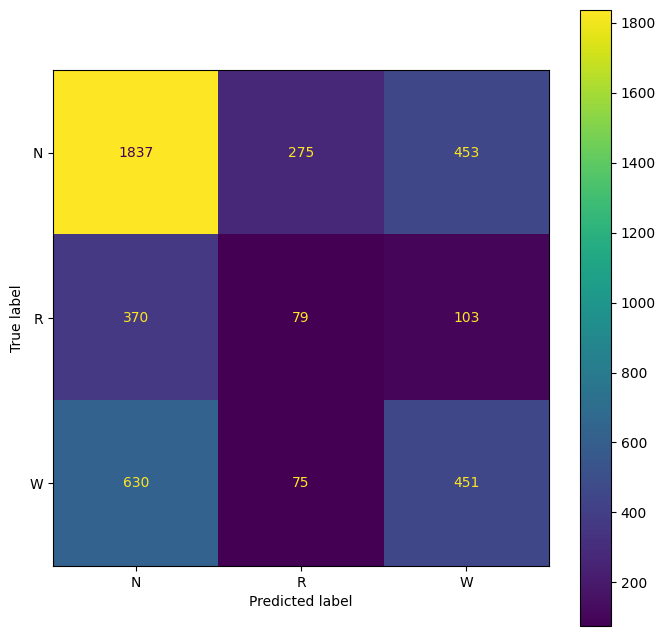

In [68]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_true_merged, y_pred_merged), display_labels=["N","R","W"]).plot(ax=ax)
fig.savefig(f"reports/figures/confusion_matrix_U=25_C=3_M=TCN.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [69]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = test_model(model, test_dl, DEVICE)

print(classification_report(y_true, y_pred, target_names=lb.classes_))

Generalization Error: 2.059, Accuracy 0.334
              precision    recall  f1-score   support

          N1       0.08      0.26      0.12       293
          N2       0.52      0.40      0.45      2031
          N3       0.02      0.02      0.02       241
           R       0.18      0.14      0.16       552
           W       0.45      0.39      0.42      1156

    accuracy                           0.33      4273
   macro avg       0.25      0.24      0.23      4273
weighted avg       0.40      0.33      0.36      4273



In [70]:
# import matplotlib.pyplot as plt 

# fig, ax = plt.subplots(figsize=(8, 8))
# ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=lb.classes_).plot(ax=ax)
# fig.savefig(f"reports/figures/confusion_matrix_U=25_C=5_M=TCN.png", dpi=150, bbox_inches="tight")
# plt.show()
# plt.close(fig)